# Cybersecurity Bivariate EDA and Correlation Analysis

**Author:** Usha Priya Krishnasamy  
**Project Type:** Exploratory data analysis, correlation review, and relationship visualization  
**Datasets:** BETH Honeypot, Cybersecurity Attacks Dataset, and UNSW-NB15  

## Project Overview

This notebook performs bivariate exploratory data analysis across three public cybersecurity datasets used for threat detection, attack classification, and anomaly detection.

The purpose is to examine relationships between pairs of variables, identify highly correlated features, review possible redundancy, and visualize how selected features relate to suspicious or malicious activity.

This notebook supports a larger capstone project focused on cybersecurity attack classification and anomaly detection.

## Note

This version keeps the saved outputs and plots from the original run so the notebook can be reviewed on GitHub without rerunning the datasets.

The raw datasets are not included in this repository. The analysis was developed using public cybersecurity datasets.

## Analysis Plan

For each dataset, this notebook reviews:

- Pairwise correlations among numeric or encoded variables
- Scatterplots for highly correlated feature pairs
- Pairplots for selected feature groups
- Bar plots for attack-label and category-based comparison
- Redundant or highly correlated features
- Possible confounding variables and modeling implications
- Short conclusions about relationship patterns and feature usefulness

### 1. BETH Honeypot Dataset

The BETH dataset contains host-level honeypot logs with process, host, user, event, suspicious-label, and malicious-label information.

The bivariate analysis focuses on relationships between system-log features and the `sus` and `evil` labels. The goal is to identify correlated variables, possible redundant features, and process-level patterns associated with suspicious or malicious activity.

In [ ]:
#     https://www.kaggle.com/datasets/katehighnam/beth-dataset
# Dataset loading 
 

#!pip install kagglehub
import kagglehub
import pandas as pd
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
print("Kagglehub version:", kagglehub.__version__)
#!pip install --upgrade kagglehub


beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")

print("Path to dataset files:", beth_dataset_path)

import os

# List all files in the dataset directory
print(os.listdir(beth_dataset_path))

# List of kernel log files- Merge and split the training,test and validation to balance classes ( evil=1 malicious activity)across the datasets
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]

dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)

# Verify
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)




Kagglehub version: 0.3.13
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']


#### Correlation Analysis Note

Categorical variables such as `processName`, `hostName`, and `eventName` are label encoded in this section for exploratory correlation review.

These encoded correlations should be interpreted carefully because label encoding converts text categories into numbers, but those numbers do not represent true numeric order.

Therefore, these correlations are useful for screening possible relationships, not for proving causality.

#### Encoded Correlation Analysis

Top 5 highly correlated variable pairs:
threadId     processId    0.997771
userId       evil         0.974667
sus          userId       0.963584
evil         sus          0.947622
processName  evil         0.911313
dtype: float64


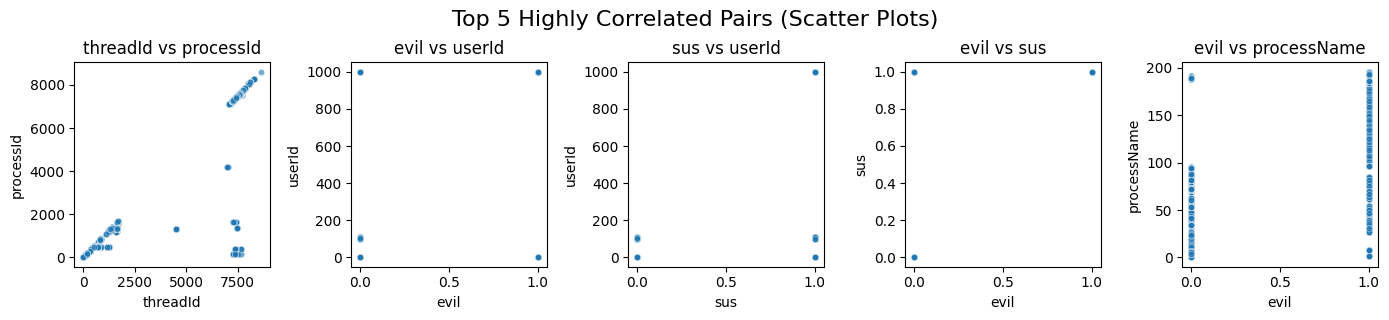

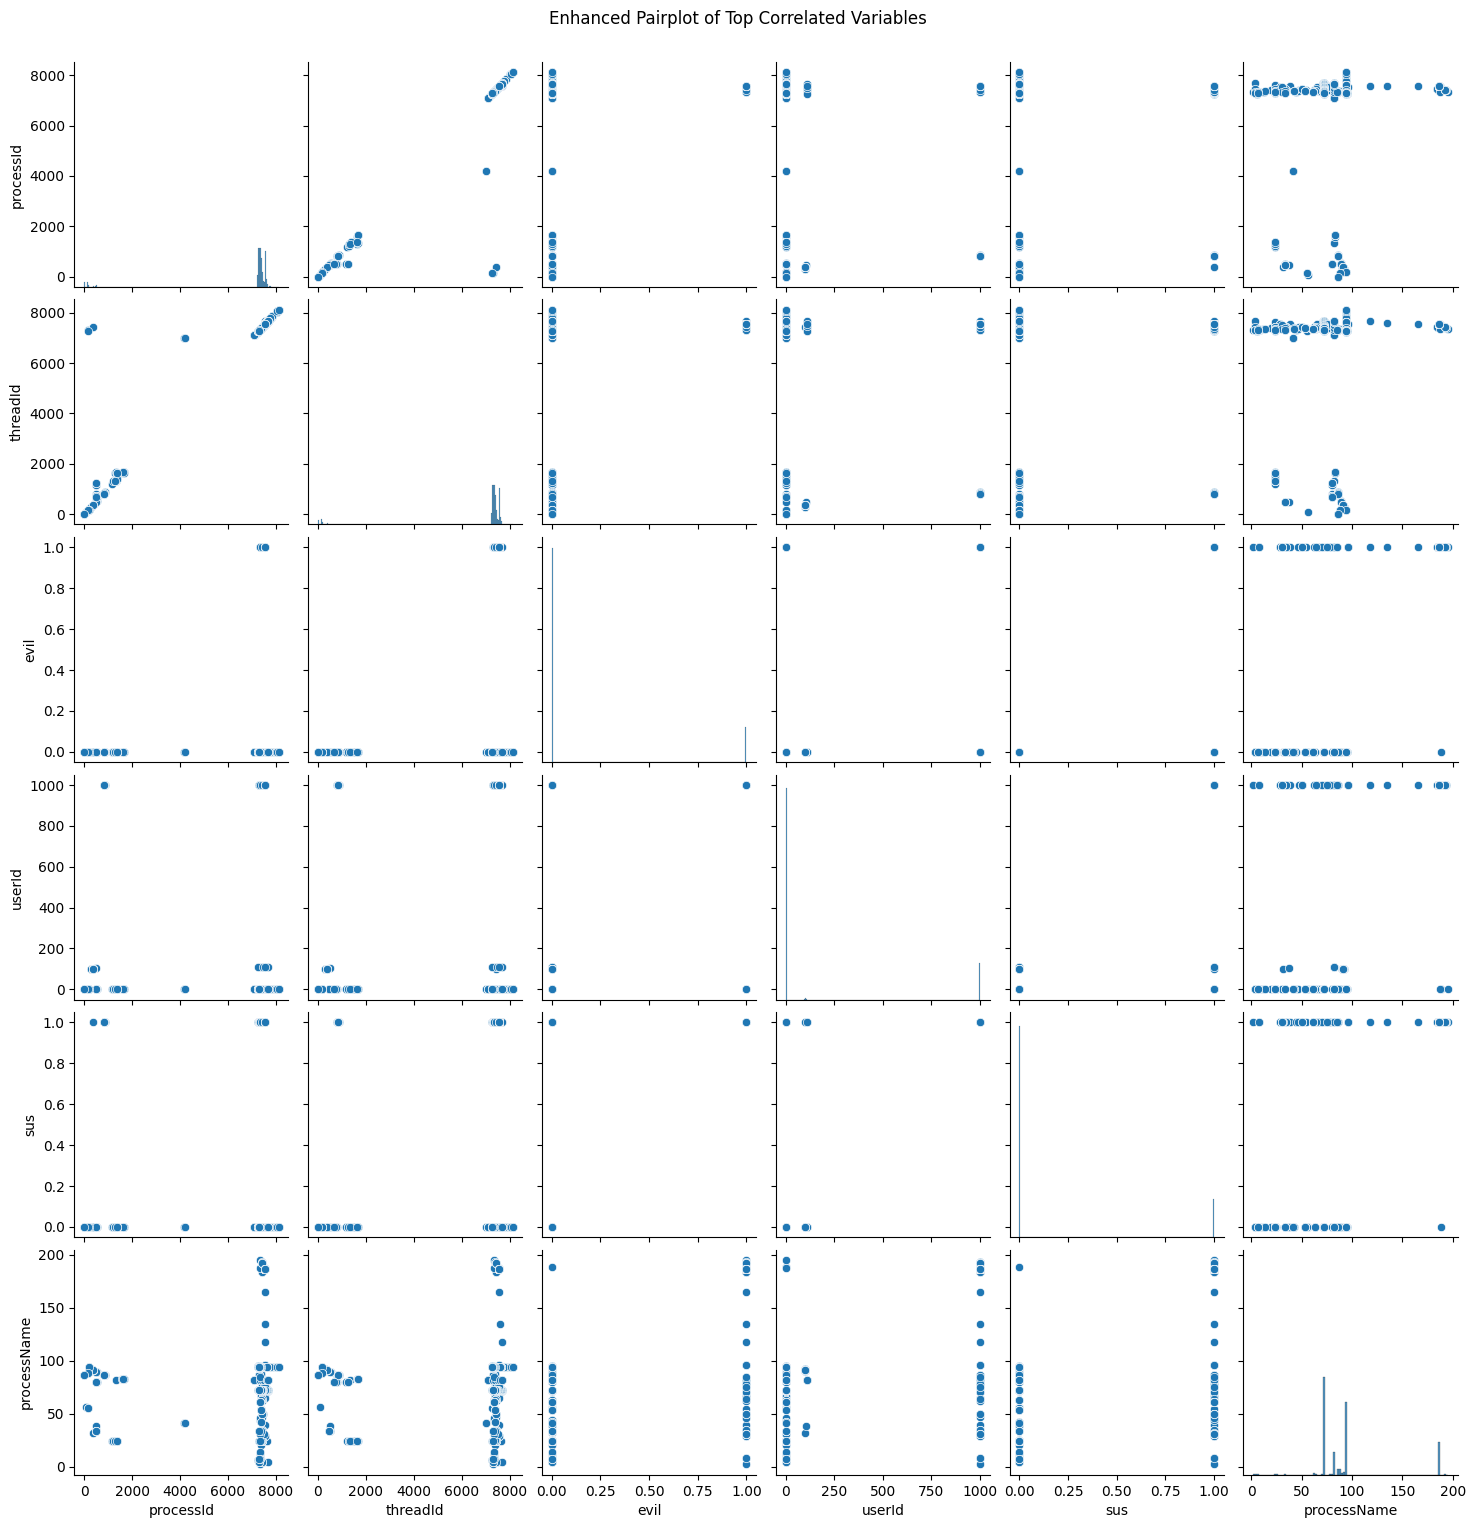

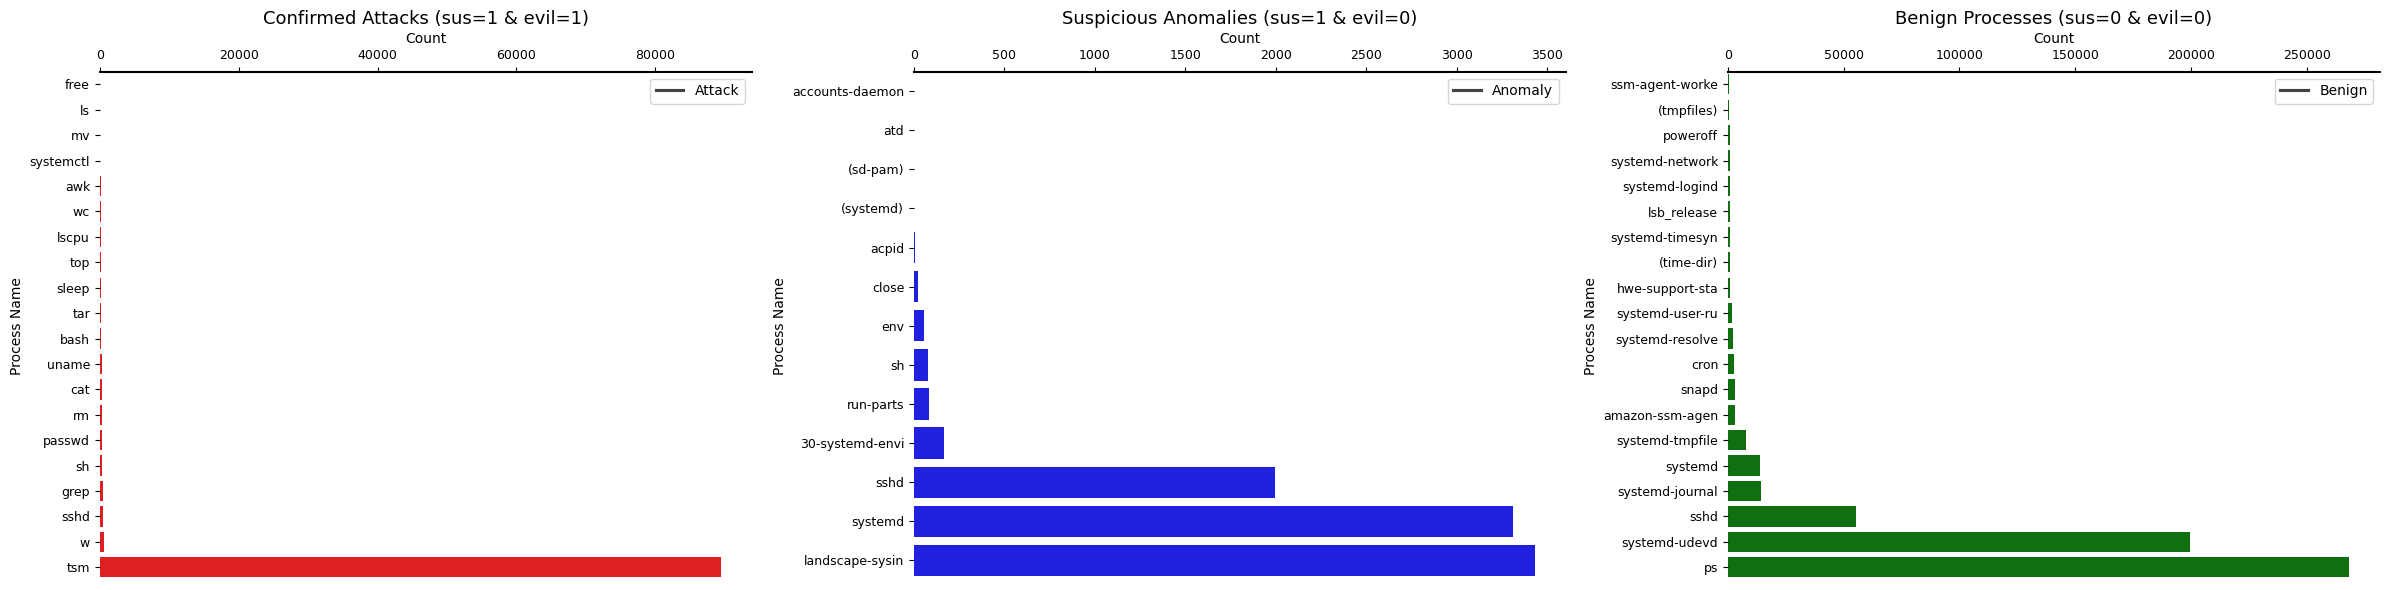

In [ ]:

numeric_columns = ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'eventId', 'argsNum', 'returnValue', 'sus', 'evil']
df_encoded_beth = df_beth[numeric_columns].copy()

# Categorical columns to encode
categorical_columns = ['processName', 'hostName', 'eventName', 'stackAddresses', 'args']

# Initialize dictionary to store encoders
encoders = {}

# Encode each categorical column and add to new DataFrame
for column in categorical_columns:
  
    
    # Initialize and fit LabelEncoder
    encoders[column] = LabelEncoder()
    df_encoded_beth[column] = encoders[column].fit_transform(df_beth[column])

 

numeric_columns_beth = df_encoded_beth.select_dtypes(include=['number'])

corr_matrix = numeric_columns_beth.corr()

# 3. Find top 5 highest correlated pairs (excluding self-correlations)
corr_unstacked = corr_matrix.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]  # Remove 1.0 (self-correlation)
top5_corr = corr_unstacked.sort_values(ascending=False).drop_duplicates().head(5)
# 4. Print top 5 correlated variable pairs
print("Top 5 highly correlated variable pairs:")
print(top5_corr)

 

# List of top correlated variable pairs
top_pairs = [
    ('threadId', 'processId'),
    ( 'evil','userId'),
    ('sus', 'userId'),
    ('evil', 'sus'),
    ('evil','processName' )
]

# Create subplots: 1 row, 5 columns
fig, axes = plt.subplots(1, 5, figsize=(14, 3))

# Plot each pair
for i, (x_var, y_var) in enumerate(top_pairs):
    sns.scatterplot(
        data=df_encoded_beth,
        x=x_var,
        y=y_var,
        ax=axes[i],
        alpha=0.6,
        s=20
    )
    axes[i].set_title(f"{x_var} vs {y_var}")

plt.tight_layout()
plt.suptitle("Top 5 Highly Correlated Pairs (Scatter Plots)", y=1.05, fontsize=16)
plt.show()


# Sample a manageable subset
df_sampled = df_encoded_beth.sample(n=10000, random_state=42)

# Focus on key variables with processName_encoded hue
columns_for_pairplot = ['processId', 'threadId', 'evil', 'userId', 'sus', 'processName']
sns.pairplot(df_sampled[columns_for_pairplot])
plt.suptitle("Enhanced Pairplot of Top Correlated Variables", y=1.02)
plt.show()
## Process Comparison by Security Label
sus_evil_1 = df_beth[(df_beth['sus'] == 1) & (df_beth['evil'] == 1)]  # Confirmed Attacks
sus_evil_0 = df_beth[(df_beth['sus'] == 1) & (df_beth['evil'] == 0)]  # Anomalies
benign = df_beth[(df_beth['sus'] == 0) & (df_beth['evil'] == 0)]      # Benign

# Count top 20 process names in each group (sorted for clean horizontal bars)
count_sus_evil_1 = sus_evil_1['processName'].value_counts().head(20).sort_values(ascending=True)
count_sus_evil_0 = sus_evil_0['processName'].value_counts().head(20).sort_values(ascending=True)
count_benign = benign['processName'].value_counts().head(20).sort_values(ascending=True)

# Set up 3 subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=False)

# Plot settings for each subplot
plot_data = [
    (count_sus_evil_1, 'red', 'Confirmed Attacks (sus=1 & evil=1)', 'Attack'),
    (count_sus_evil_0, 'blue', 'Suspicious Anomalies (sus=1 & evil=0)', 'Anomaly'),
    (count_benign, 'green', 'Benign Processes (sus=0 & evil=0)', 'Benign')
]

# Loop to draw each plot
for ax, (data, color, title, legend_label) in zip(axes, plot_data):
    sns.barplot(x=data.values, y=data.index, ax=ax, color=color)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Count')
    ax.set_ylabel('Process Name')
    ax.tick_params(axis='y', labelsize=9)
    ax.legend([legend_label])

    # Style adjustments
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(True)
    ax.spines['top'].set_linewidth(1.5)

    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='x', labelsize=9)

# Adjust layout spacing
plt.subplots_adjust(wspace=0.5)
plt.tight_layout()
plt.show()



### BETH Dataset Conclusion

The BETH dataset is useful for bivariate cybersecurity analysis because it includes process, host, user, event, suspicious-label, and malicious-label features.

The correlation analysis shows a strong relationship between `threadId` and `processId`, suggesting possible redundancy. One of these features may need to be removed or reviewed during feature selection to reduce multicollinearity.

The relationship between `sus` and `evil` is important because suspicious events and confirmed malicious events are related but not identical. This distinction is useful for separating anomaly detection from attack classification.

The process-based bar plots show that some process names appear more frequently in suspicious or malicious records. These patterns can help guide feature engineering for host-level threat detection.

Because several features are categorical or binary, correlation values should be interpreted as exploratory signals rather than proof of direct causality.

Overall, BETH is useful for identifying host-level behavioral patterns, but later modeling should handle class imbalance, redundant identifiers, and encoded categorical variables carefully.

### 2. Cybersecurity Attacks Dataset

The Cybersecurity Attacks dataset contains network-security event records with packet details, anomaly scores, attack types, severity levels, action outcomes, alerts, and network segment information.

The bivariate analysis focuses on relationships between anomaly scores, attack types, severity levels, IDS/IPS alerts, and response actions.


In [12]:
##   https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks
# Dataset loading


CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
import os

# List all files in the dataset directory
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)
#print(df_csa.columns.to_list())
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 'Device Information','Geo-location Data','Proxy Information','Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)
df_new_csa["Malware Indicators"] = df_new_csa["Malware Indicators"].fillna("None Detected")
df_new_csa["Alerts/Warnings"] = df_new_csa["Alerts/Warnings"].fillna("No Alert")


csa_numeric_columns=df_new_csa.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(csa_numeric_columns.to_list())
print('\n')

csa_categorical_columns=df_new_csa.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(csa_categorical_columns.to_list())

Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\32
['cybersecurity_attacks.csv', 'README.md']
Numeric columns in the dataset:

['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']


Categorical columns in the dataset:

['Timestamp', 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']


#### Correlation Analysis Note

This dataset contains many categorical security-event fields. Label encoding is used only for exploratory relationship review.

Because encoded categories do not have true numeric order, correlation results should be interpreted cautiously.

Bar plots and grouped summaries are more useful for understanding relationships between attack type, action taken, severity level, and alert fields.

#### Encoded Correlation Analysis


🔝 Top 5 Feature Pairs with Highest Correlation (Excluding Self-Correlation):

Packet Type vs Action Taken: 0.0130
IDS/IPS Alerts vs Network Segment: 0.0126
Firewall Logs vs Weekday: 0.0121
Month vs Action Taken: 0.0108
Month vs Source Port: 0.0094
Columns selected for pairplot: ['Weekday', 'Action Taken', 'Month', 'Source Port', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts', 'Packet Type']


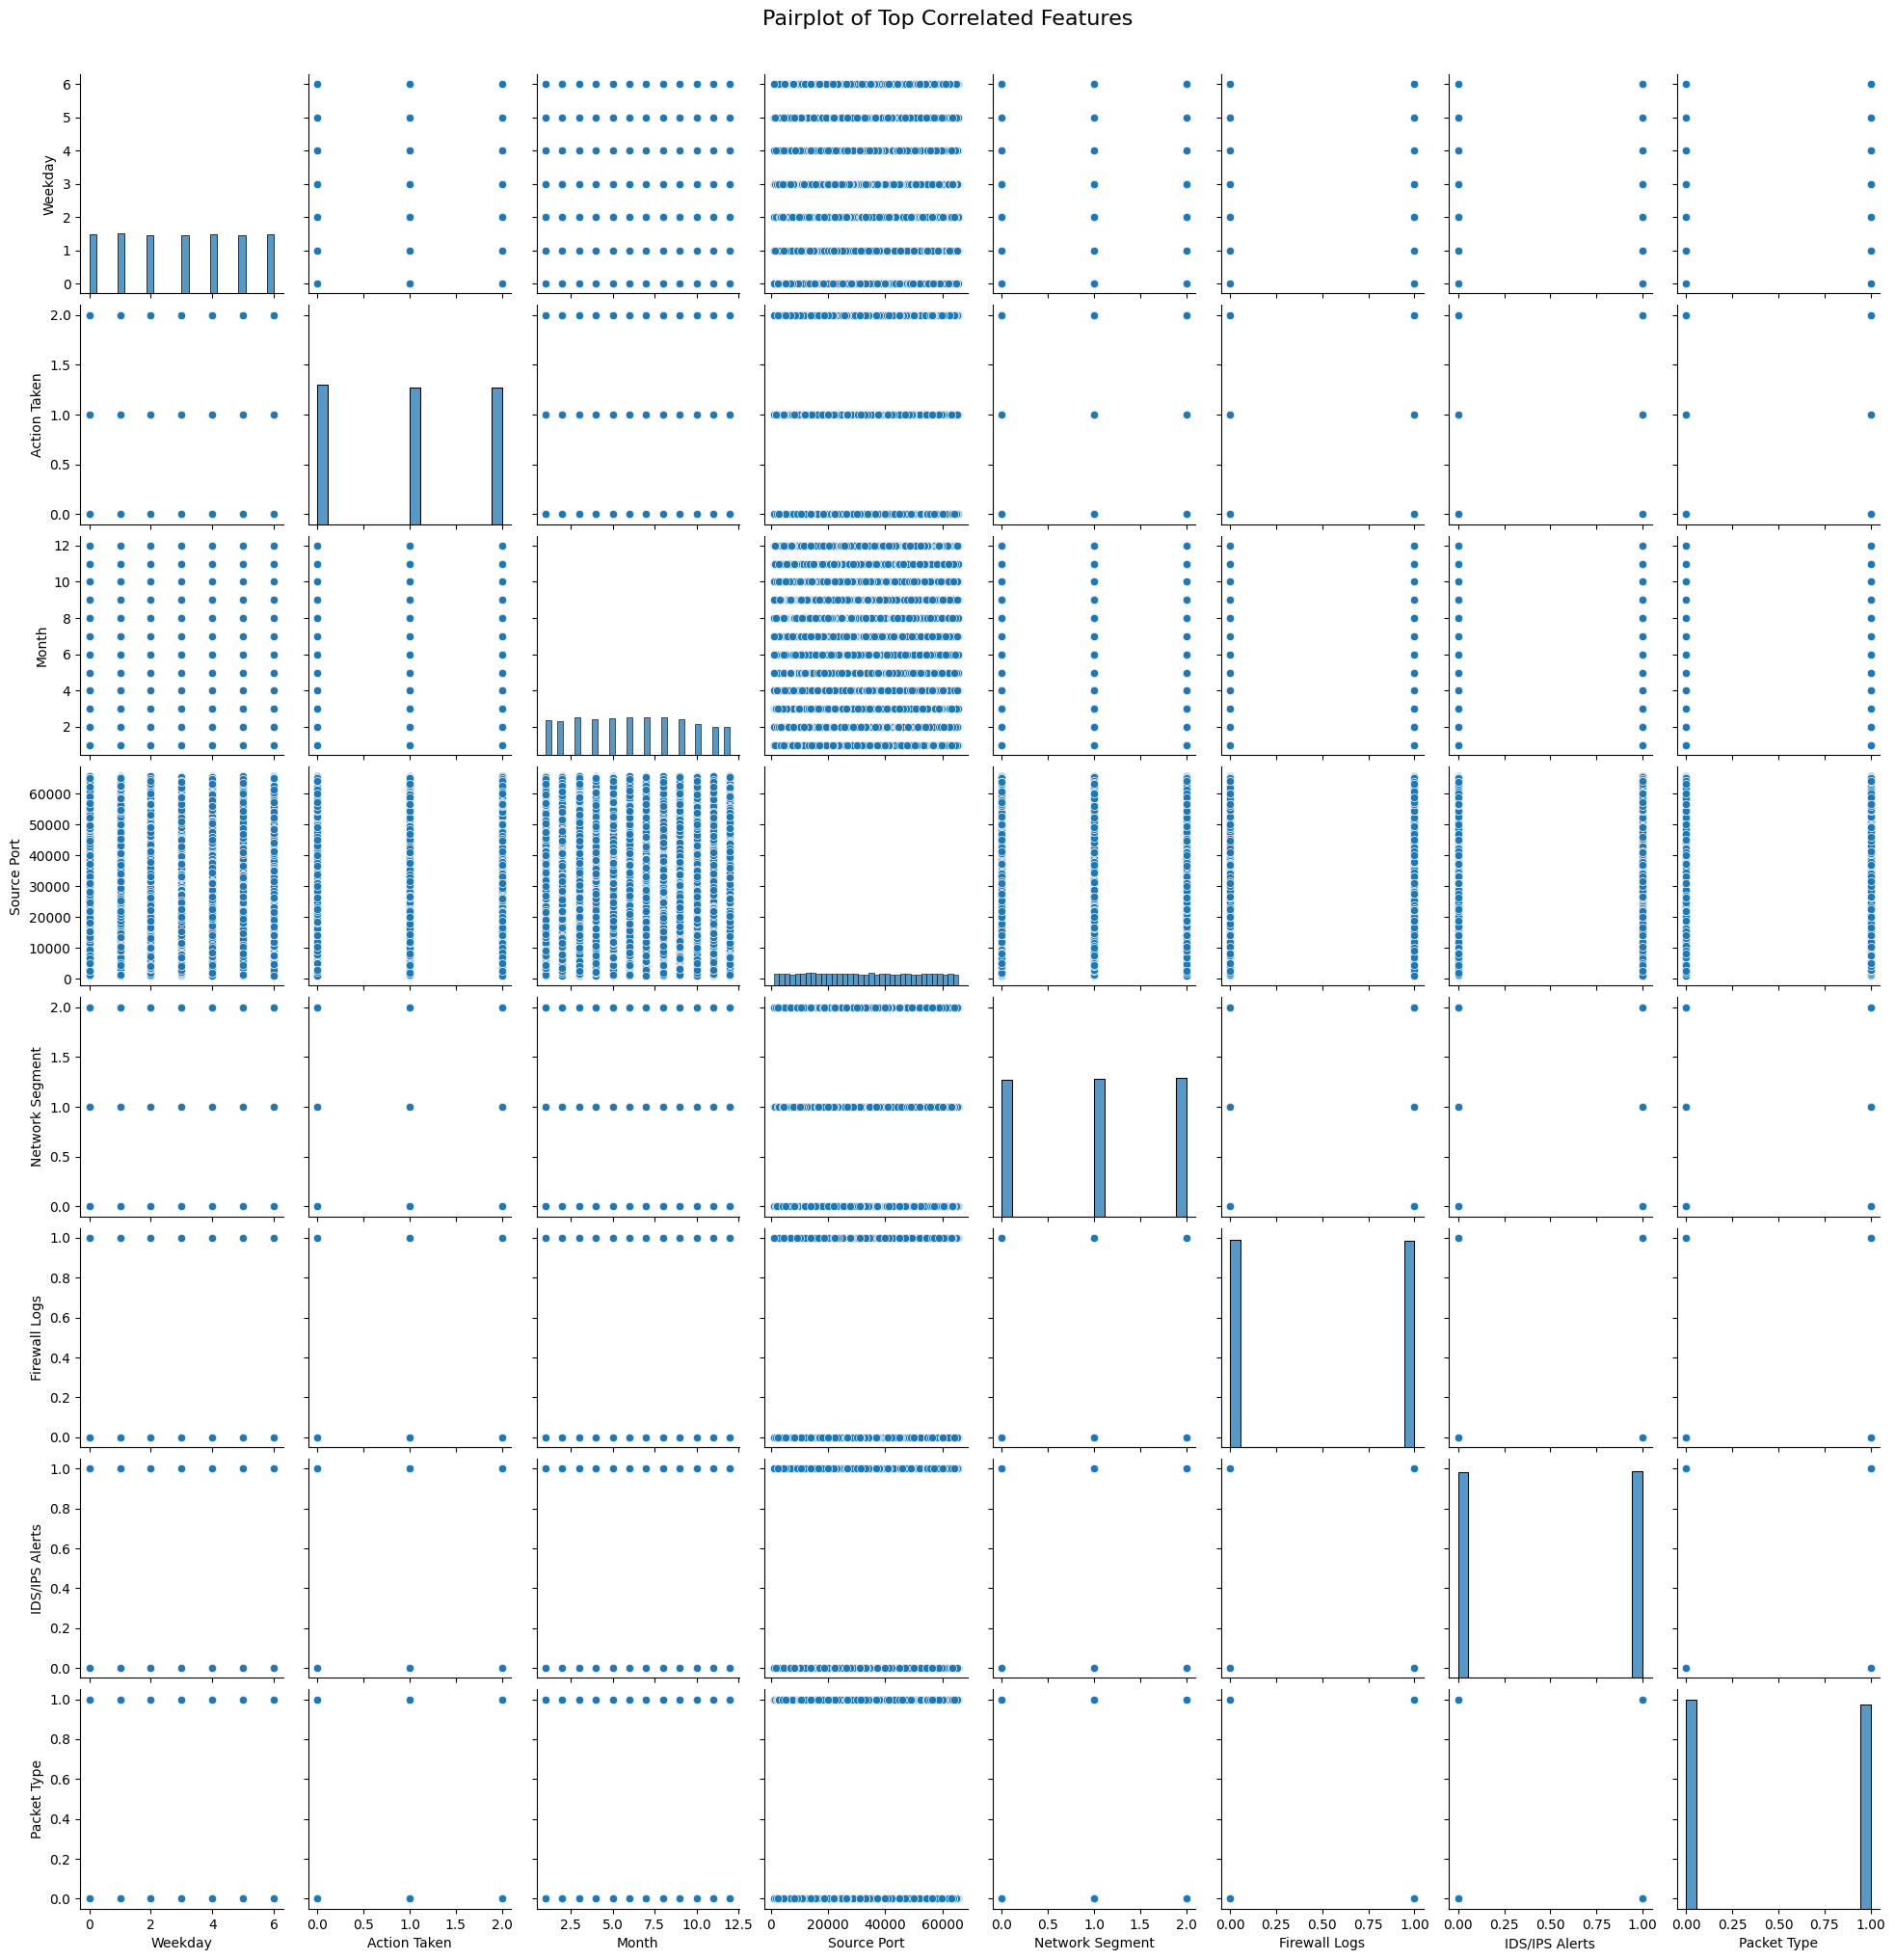

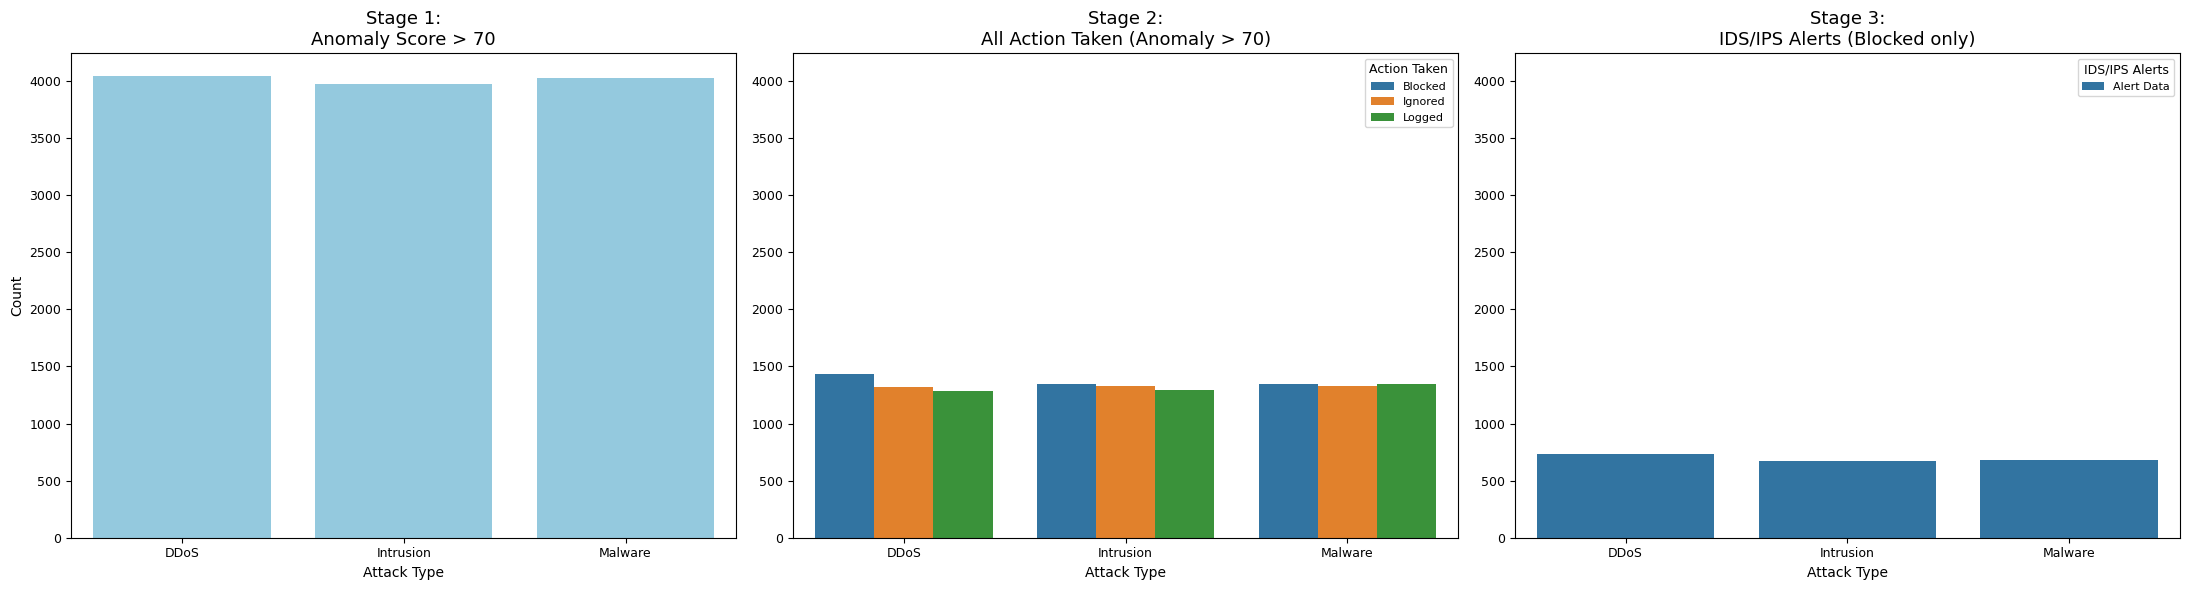

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import ipaddress

# Copy original dataset to avoid changes to df_csa
df_csa_encoded = df_new_csa.copy()

# Define categorical columns (assuming csa_categorical_columns is defined elsewhere)
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

# Convert Timestamp to datetime and verify
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
if df_csa_encoded['Timestamp'].dtype != 'datetime64[ns]':
    print("Warning: Timestamp column is not datetime64[ns]. Checking for issues...")
    print(df_csa_encoded['Timestamp'].head())  # Debug: Check the first few values
    df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with NaT if needed

# Extract time components
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode all categorical columns
label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Combine all numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number')
#Missing-value handling for `Malware Indicators` and `Alerts/Warnings` should be assigned back to the dataframe 
#in a future cleaned version of the notebook.


# Handle any remaining NaN values
df_features = df_features.fillna(0)

# Correlation matrix
full_corr = df_features.corr()

# Print top 5 correlated feature pairs
top_pairs = full_corr.unstack().sort_values(ascending=False).drop_duplicates().head(11)
top_pairs = top_pairs[top_pairs < 1]
print("\n🔝 Top 5 Feature Pairs with Highest Correlation (Excluding Self-Correlation):\n")
for pair, corr in top_pairs.head(5).items():
    print(f"{pair[0]} vs {pair[1]}: {corr:.4f}")

cols = set()
for (col1, col2) in top_pairs.head(5).index:
    cols.add(col1)
    cols.add(col2)

cols = list(cols)
print("Columns selected for pairplot:", cols)

# Now plot pairplot on these columns
sns.pairplot(df_csa_encoded[cols], diag_kind='hist')
plt.suptitle("Pairplot of Top Correlated Features", fontsize=16, y=1.02)
plt.show()
###################################################################bar plot for analysis since this is balanced dataset and weak correlation############
#import

 
# Step 1: Filter Anomaly Score > 70
high_anomaly_df = df_new_csa[df_new_csa['Anomaly Scores'] > 70]

# Step 2: Group by Attack Type (for Stage 1)
group1 = high_anomaly_df.groupby('Attack Type').size().reset_index(name='Count')

# Step 3: Group by Attack Type + Action Taken (for Stage 2 - show ALL actions)
group2 = high_anomaly_df.groupby(['Attack Type', 'Action Taken']).size().reset_index(name='Count')

# Step 4: Only for 'Blocked' actions - group by Attack Type + IDS/IPS Alerts (Stage 3)
blocked_df = high_anomaly_df[high_anomaly_df['Action Taken'] == 'Blocked']
group3 = blocked_df.groupby(['Attack Type', 'IDS/IPS Alerts']).size().reset_index(name='Count')

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
plt.subplots_adjust(wspace=0.3)

# --- Formatting helper ---
def format_subplot(ax, title):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Attack Type', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(axis='x', labelrotation=0, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.yaxis.set_tick_params(labelleft=True)

# Plot 1: Total high anomaly attacks
sns.barplot(data=group1, x='Attack Type', y='Count', ax=axes[0], color='skyblue')
format_subplot(axes[0], 'Stage 1:\nAnomaly Score > 70')

# Plot 2: Show all actions taken (Logged, Blocked, Ignored...)
sns.barplot(data=group2, x='Attack Type', y='Count', hue='Action Taken', ax=axes[1])
format_subplot(axes[1], 'Stage 2:\nAll Action Taken (Anomaly > 70)')
axes[1].legend(title='Action Taken', fontsize=8, title_fontsize=9, loc='upper right')

# Plot 3: Show only alerts under Blocked action
sns.barplot(data=group3, x='Attack Type', y='Count', hue='IDS/IPS Alerts', ax=axes[2])
format_subplot(axes[2], 'Stage 3:\nIDS/IPS Alerts (Blocked only)')
axes[2].legend(title='IDS/IPS Alerts', fontsize=8, title_fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()


### Cybersecurity Attacks Dataset Conclusion

The Cybersecurity Attacks dataset is useful for exploring relationships between anomaly scores, attack types, severity levels, IDS/IPS alerts, and response actions.

Traditional correlation analysis is limited for this dataset because many important fields are categorical. Label encoding helps create an exploratory correlation matrix, but the results should not be interpreted as true numeric relationships.

The anomaly-score filtering step helps identify higher-risk records. Reviewing records with anomaly scores above 70 provides a practical way to compare attack types, actions taken, and alert behavior.

The staged bar plots are useful because they show how high-anomaly records are distributed by attack type, action taken, and IDS/IPS alert status.

This dataset appears more structured and balanced than typical real-world cybersecurity traffic, so it should be interpreted cautiously. It is useful for exploratory analysis and pipeline testing, but it should not be treated as the strongest evidence for production-level threat detection.

Possible confounding variables include severity level, alert status, action taken, network segment, and attack type. These variables may influence each other and should be reviewed carefully before modeling.

### 3. UNSW-NB15 Intrusion Detection Dataset

The UNSW-NB15 dataset contains network-flow records with protocol, service, state, traffic-volume features, timing features, attack categories, and binary attack labels.

The bivariate analysis focuses on relationships among traffic-flow variables, highly correlated network features, attack labels, and attack categories.


In [14]:
# https://doi.org/10.34740/KAGGLE/DSV/9350725
# Dataset loading

path = kagglehub.dataset_download("dhoogla/unswnb15")

# Load the training and testing  set parquet file into DataFrame
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))

unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns.to_list())
print(f"Count of numeric columns: {len(unsw_numeric_columns)}")

print('\n')

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns.to_list())
print(f"Count of categorical columns: {len(unsw_categorical_columns)}")
 

Numeric columns in the dataset:

['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'label']
Count of numeric columns: 32


Categorical columns in the dataset:

['proto', 'service', 'state', 'attack_cat']
Count of categorical columns: 4


#### Correlation Analysis Note
The UNSW-NB15 correlation analysis uses numeric network-flow features such as packet counts, byte counts, loss counts, timing features, and traffic-rate variables.

These correlations are useful for identifying redundant or highly related features before modeling.

Correlation values should be interpreted as relationship signals, not causal proof. Strong correlation may indicate multicollinearity, so highly related features should be reviewed during feature selection.

Top 5 Highly Correlated Variable Pairs:
dbytes vs dloss: 0.9965
sloss vs sbytes: 0.9961
swin vs dwin: 0.9901
dpkts vs dloss: 0.9786
dbytes vs dpkts: 0.9719


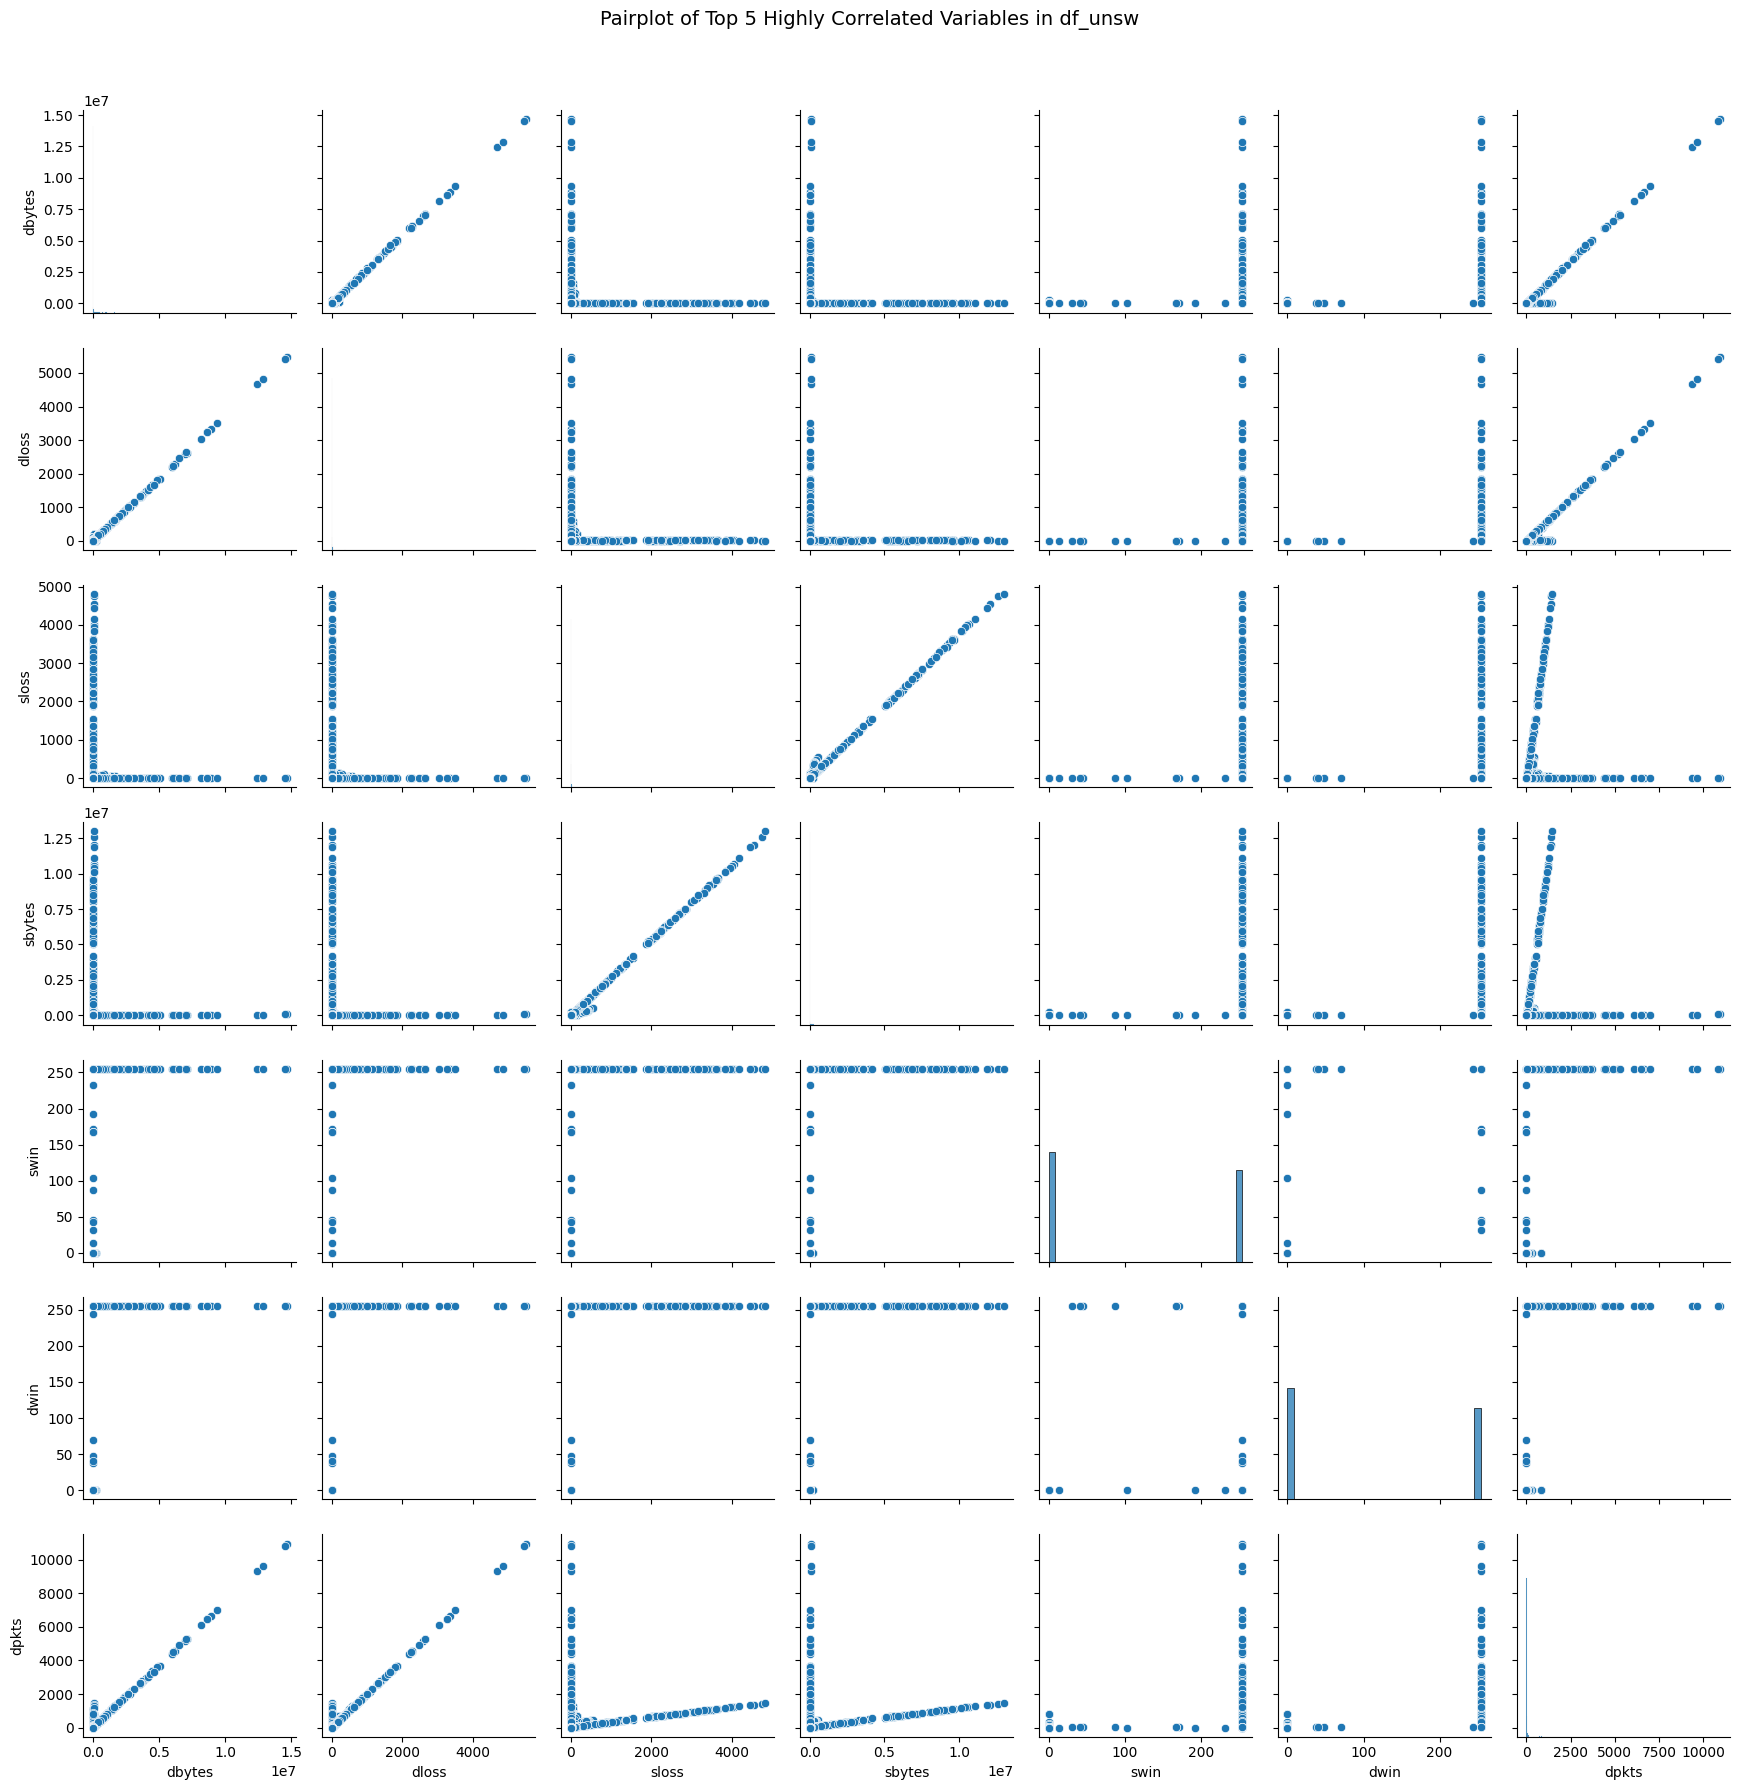

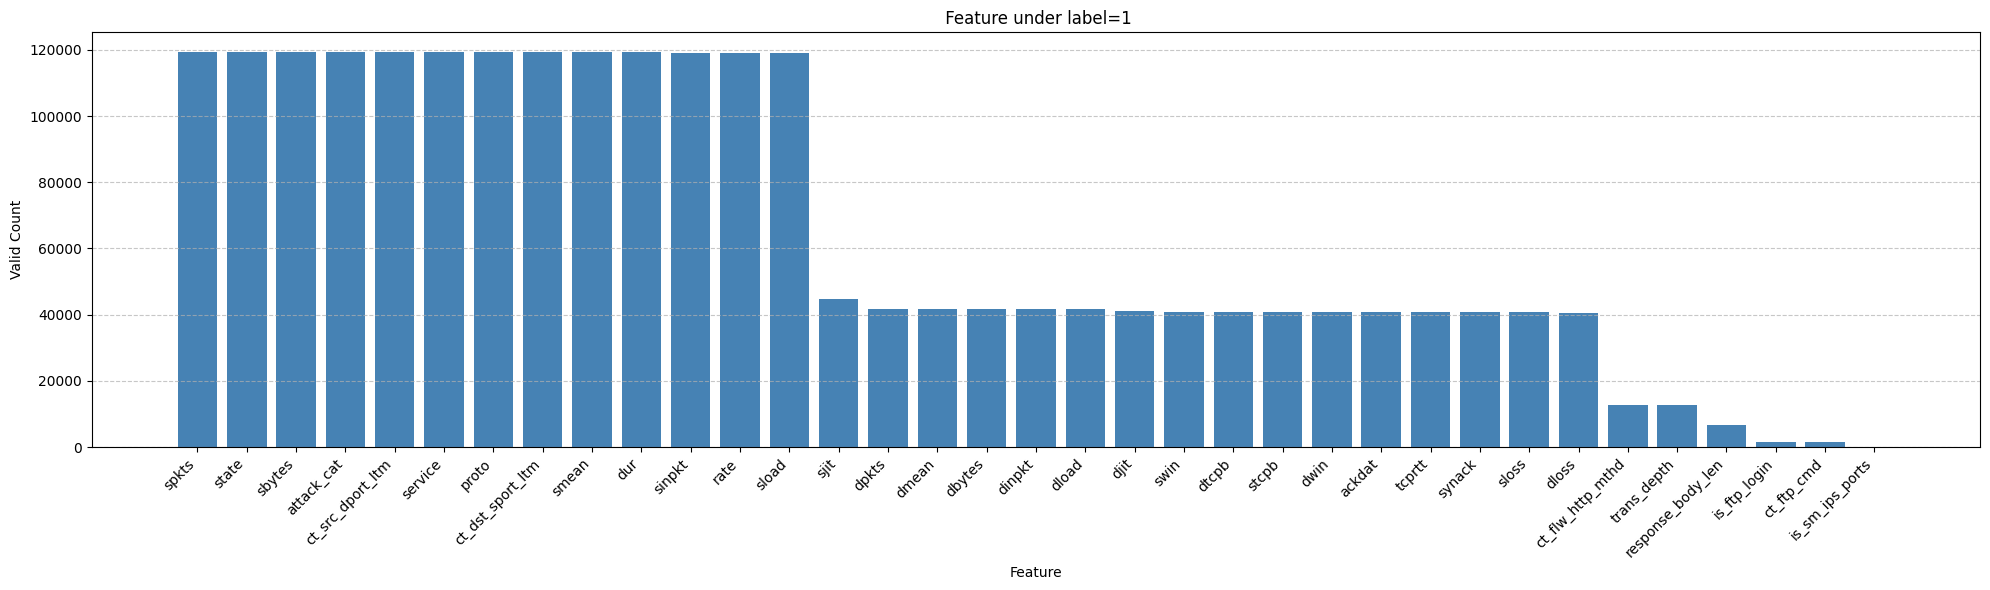

['spkts', 'sbytes', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'smean', 'dur', 'sinpkt', 'rate', 'sload', 'sjit', 'dpkts']


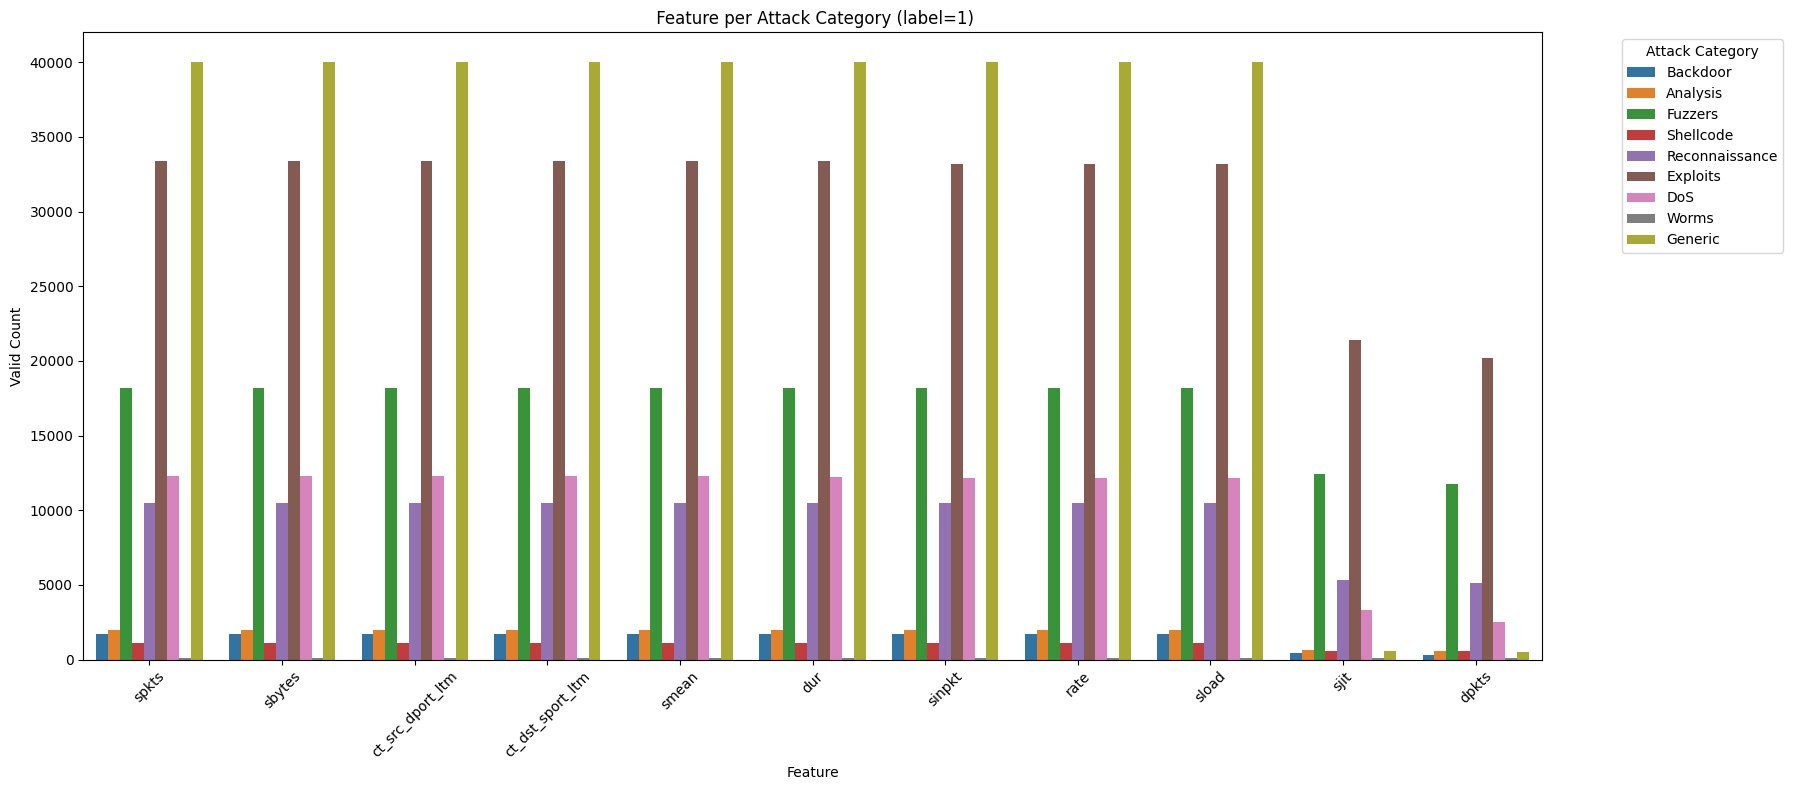

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_columns = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 
                   'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 
                   'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 
                   'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 
                   'is_sm_ips_ports', 'label']

df_numeric = df_unsw[numeric_columns]

# Compute correlation matrix
correlation_matrix = df_numeric.corr()

# Extract top 5 correlated pairs (excluding self-correlations)
correlations = correlation_matrix.unstack().sort_values(ascending=False).drop_duplicates()
top_correlations = correlations[correlations < 1].head(5)

# Print top 5 highly correlated variable pairs
print("Top 5 Highly Correlated Variable Pairs:")
for pair, corr in top_correlations.items():
    print(f"{pair[0]} vs {pair[1]}: {corr:.4f}")


    ########################################################################################################################################################3
top_vars = ['dbytes', 'dloss', 'sloss', 'sbytes', 'swin', 'dwin', 'dpkts']
df_top = df_unsw[top_vars]

# Plot pairplot
sns.pairplot(df_top)
plt.suptitle('Pairplot of Top 5 Highly Correlated Variables in df_unsw', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


# Step 1: Filter label == 1
df_label1 = df_unsw[df_unsw['label'] == 1]

# Step 2: Define columns
numeric_columns = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 
                   'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 
                   'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 
                   'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 
                   'is_sm_ips_ports']
categorical_columns = ['proto', 'service', 'state', 'attack_cat']

# Step 3: Count valid values
valid_counts = {}

for col in numeric_columns:
    valid_counts[col] = df_label1[col][(df_label1[col].notnull()) & (df_label1[col] != 0)].count()

for col in categorical_columns:
    valid_counts[col] = df_label1[col][(df_label1[col].notnull()) & (df_label1[col].str.strip() != '')].count()

# Step 4: Convert to DataFrame
valid_counts_df = pd.DataFrame.from_dict(valid_counts, orient='index', columns=['Valid Count (label=1)'])
valid_counts_df = valid_counts_df.sort_values(by='Valid Count (label=1)', ascending=False)
plt.figure(figsize=(20, 6))  # Adjust width and height here
plt.bar(valid_counts_df.index, valid_counts_df['Valid Count (label=1)'], color='steelblue')
plt.title(' Feature under label=1')
plt.xlabel('Feature')
plt.ylabel('Valid Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
 

# Define top 10 features manually
high_features = ['spkts', 'state', 'sbytes', 'ct_src_dport_ltm','attack_cat',
                  'service', 'proto', 'ct_dst_sport_ltm', 'smean', 'dur','sinpkt','rate','sload','sjit','dpkts']
 

# Filter only numerical columns from this list that exist in your DataFrame
top101_features = [col for col in high_features if col in df_unsw.columns and pd.api.types.is_numeric_dtype(df_unsw[col])]

print(top101_features)

# Filter only label == 1 data
df_label1 = df_unsw[df_unsw['label'] == 1]

# Create long-form DataFrame: each row is (feature, attack_cat, non-zero count)
plot_data = []

for feature in top101_features:
    for attack in df_label1['attack_cat'].dropna().unique():
        subset = df_label1[df_label1['attack_cat'] == attack]
        
        if pd.api.types.is_numeric_dtype(subset[feature]):
            valid_count = subset[feature][(subset[feature].notnull()) & (subset[feature] != 0)].count()
        else:
            valid_count = subset[feature][(subset[feature].notnull()) & (subset[feature].astype(str).str.strip() != '')].count()
        
        plot_data.append({'feature': feature, 'attack_cat': attack, 'count': valid_count})

df_plot = pd.DataFrame(plot_data)

# Plot
plt.figure(figsize=(18, 8))
sns.barplot(data=df_plot, x='feature', y='count', hue='attack_cat', errorbar=None, palette='tab10')

plt.title(' Feature per Attack Category (label=1)')
plt.xlabel('Feature')
plt.ylabel('Valid Count')
plt.xticks(rotation=45)
plt.legend(title='Attack Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### UNSW-NB15 Dataset Conclusion

The UNSW-NB15 dataset is useful for bivariate network intrusion detection analysis because it contains traffic-flow features, categorical network attributes, attack categories, and binary attack labels.

The correlation analysis shows strong relationships among traffic-volume and packet-loss variables, such as byte counts, packet counts, and loss counts. These relationships are expected in network-flow data but may create redundancy during modeling.

Highly correlated features such as `dbytes`, `dloss`, `sbytes`, and `sloss` should be reviewed during feature selection to reduce multicollinearity.

The pairplots help visualize relationships among the strongest correlated traffic features, while the attack-label and attack-category plots help identify which features are active or informative in malicious records.

Outliers and extreme values should not be removed automatically because unusual traffic behavior may represent scanning, denial-of-service activity, data exfiltration, or other attack patterns.

Possible confounding variables include protocol, service, connection state, traffic volume, and attack category. These variables may affect the relationship between network-flow features and the binary attack label.

Overall, UNSW-NB15 is one of the strongest datasets in this project for network-level intrusion detection, but correlated features, skewed traffic variables, and attack-category imbalance should be handled carefully before modeling.

# Overall Bivariate EDA Conclusion

Across the three cybersecurity datasets, the bivariate analysis shows that the data are usable for academic machine learning analysis, but each dataset requires careful interpretation.

BETH is useful for host-level behavior analysis because process, user, host, event, suspicious-label, and malicious-label relationships can support attack classification and anomaly detection.

The Cybersecurity Attacks dataset is useful for exploratory analysis of anomaly scores, attack types, alerts, and response actions, but its categorical structure limits the value of traditional correlation analysis.

UNSW-NB15 is useful for network-level intrusion detection because it contains strong relationships among traffic-flow features and attack labels. However, several features are highly correlated, so feature selection may be needed before modeling.

Overall, the bivariate EDA supports the need for careful preprocessing, categorical encoding, feature selection, and evaluation beyond accuracy. Correlation results are helpful for screening relationships, but they should not be treated as causal evidence.